In [1]:
!pip install open-clip-torch

In [2]:
!pip install av --prefer-binary
!pip install qwen-vl-utils --no-deps

In [3]:
!pip install transformers

In [4]:
!pip install accelerate

In [5]:
!pip install -U bitsandbytes>=0.46.1

In [6]:
!pip install captcha

In [7]:
!pip install multicolorcaptcha

In [8]:
import torch

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free:  {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


GPU: Tesla T4
VRAM total: 15.6 GB
VRAM free:  15.6 GB
PyTorch: 2.6.0+cu124


In [9]:
import gc
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"

surrogate_processor = AutoProcessor.from_pretrained(
    MODEL, min_pixels=256 * 28 * 28, max_pixels=256 * 28 * 28
)
surrogate_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL, quantization_config=bnb_config, device_map="auto"
)
surrogate_model.eval()
for p in surrogate_model.parameters():
    p.requires_grad = False

print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

VRAM used: 2.4 GB


Content rows: 100 → 259


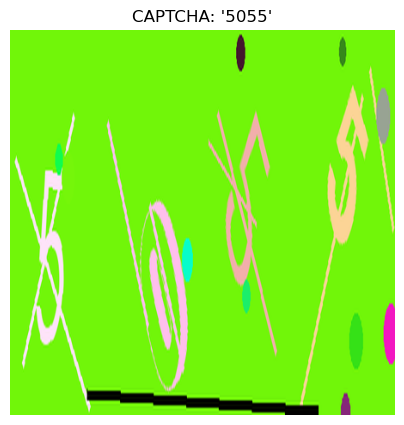

True answer  : '5055'
Tensor shape : torch.Size([1, 3, 448, 448])
Tensor range : [0.000, 1.000]


In [18]:
# Cell: Complete numeric CAPTCHA generation — clean final version
from multicolorcaptcha import CaptchaGenerator
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Generate
generator = CaptchaGenerator(captcha_size_num=2)
captcha = generator.gen_captcha_image(difficult_level=1)
captcha_text_numeric = captcha.characters

# RGBA → RGB, dynamic black band crop, resize
raw_rgb = np.array(captcha.image)[:, :, :3]
row_brightness = raw_rgb.mean(axis=(1, 2))
content_rows = np.where(row_brightness > 20)[0]
r_min, r_max = content_rows[0], content_rows[-1]
print(f"Content rows: {r_min} → {r_max}")

cropped = raw_rgb[r_min:r_max, :, :]
captcha_image_numeric = Image.fromarray(cropped).resize((448, 448), Image.LANCZOS)

# Convert to tensor
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x_clean_numeric = torch.tensor(
    np.array(captcha_image_numeric), dtype=torch.float32
).permute(2, 0, 1).unsqueeze(0).to(device) / 255.0  # [1, 3, 448, 448]

# Display
plt.figure(figsize=(5, 5))
plt.imshow(captcha_image_numeric)
plt.title(f"CAPTCHA: '{captcha_text_numeric}'")
plt.axis("off")
plt.show()

print(f"True answer  : '{captcha_text_numeric}'")
print(f"Tensor shape : {x_clean_numeric.shape}")
print(f"Tensor range : [{x_clean_numeric.min():.3f}, {x_clean_numeric.max():.3f}]")

Raw response: ```json
[
	{"bbox_2d": [0, 103, 149, 387], "label": "digit 5 on the left side"}
]
```<|im_end|>
Raw bbox from Qwen: (0,103) → (149,387)
Mapped bbox (pixels): (0,93) → (159,397)


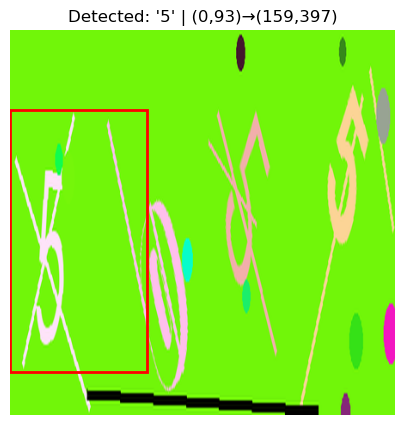

In [19]:
# Cell: Fix — regex directly on bbox_2d values, skip JSON parsing entirely
import re
import matplotlib.patches as patches

def get_first_digit_bbox(pil_image, captcha_text):
    first_digit = captcha_text[0]
    
    messages = [{"role": "user", "content": [
        {"type": "image", "image": pil_image},
        {"type": "text", "text": f"Locate the digit {first_digit} on the left side of this image. Output the bounding box only."}
    ]}]
    
    text = surrogate_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = surrogate_processor(
        text=[text], images=image_inputs,
        videos=video_inputs, return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        out = surrogate_model.generate(**inputs, max_new_tokens=50)
    response = surrogate_processor.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False
    ).strip()
    print(f"Raw response: {response}")
    
    # Directly grab the 4 numbers after "bbox_2d": [
    match = re.search(r'"bbox_2d"\s*:\s*\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]', response)
    if match:
        x1, y1, x2, y2 = [int(match.group(i)) for i in range(1, 5)]
        print(f"Raw bbox from Qwen: ({x1},{y1}) → ({x2},{y2})")
        
        # Qwen returns coords in its internal processed resolution — map back to PIL size
        W, H = pil_image.size
        x1 = int(x1 / 448 * W);  y1 = int(y1 / 448 * H)
        x2 = int(x2 / 448 * W);  y2 = int(y2 / 448 * H)
        
        pad = 10
        x1 = max(0, x1 - pad);  y1 = max(0, y1 - pad)
        x2 = min(W, x2 + pad);  y2 = min(H, y2 + pad)
        
        print(f"Mapped bbox (pixels): ({x1},{y1}) → ({x2},{y2})")
        return x1, y1, x2, y2
    else:
        print("⚠ Could not parse — falling back to left quarter")
        W, H = pil_image.size
        return 0, 0, W // 4, H

# Run
bbox = get_first_digit_bbox(captcha_image_numeric, captcha_text_numeric)
x1, y1, x2, y2 = bbox

# Visualise
fig, ax = plt.subplots(1, figsize=(5,5))
ax.imshow(captcha_image_numeric)
rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.set_title(f"Detected: '{captcha_text_numeric[0]}' | ({x1},{y1})→({x2},{y2})")
ax.axis("off")
plt.show()

In [22]:
# ── Differentiable preprocessor setup (run before attack loop) ────────
qwen_mean = torch.tensor([0.48145466, 0.4578275,  0.40821073]).view(1,3,1,1).to(device)
qwen_std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1).to(device)

static_check = surrogate_processor(
    text=["dummy"], images=[captcha_image_numeric], return_tensors="pt"
).to(device)
image_grid_thw_check = static_check.get("image_grid_thw")
PATCH_SIZE = 14; TEMPORAL_PATCH = 2; MERGE_SIZE = 2
GRID_T = int(image_grid_thw_check[0][0].item())
GRID_H = int(image_grid_thw_check[0][1].item())
GRID_W = int(image_grid_thw_check[0][2].item())
TARGET_H = GRID_H * PATCH_SIZE
TARGET_W = GRID_W * PATCH_SIZE
print(f"Qwen grid: T={GRID_T} H={GRID_H} W={GRID_W} → {TARGET_H}x{TARGET_W}")

def preprocess_differentiable(x):
    x_resized = F.interpolate(x, size=(TARGET_H, TARGET_W),
                               mode="bilinear", align_corners=False)
    x_norm = (x_resized - qwen_mean) / qwen_std
    x_t = x_norm.squeeze(0).unsqueeze(0).expand(TEMPORAL_PATCH, -1, -1, -1)
    C = 3
    patches_t = x_t.reshape(
        GRID_T, TEMPORAL_PATCH, C,
        GRID_H // MERGE_SIZE, MERGE_SIZE, PATCH_SIZE,
        GRID_W // MERGE_SIZE, MERGE_SIZE, PATCH_SIZE,
    )
    patches_t = patches_t.permute(0, 3, 6, 4, 7, 2, 1, 5, 8)
    patches_t = patches_t.reshape(
        GRID_T * GRID_H * GRID_W,
        C * TEMPORAL_PATCH * PATCH_SIZE * PATCH_SIZE
    )
    return patches_t

Qwen grid: T=1 H=32 W=32 → 448x448


Attacking: '5' → target: '6'
Total sequence length : 288
Supervised tokens     : 1 ← should be 1
Patch shape: torch.Size([1, 3, 304, 159])

LM-PGD patch attack | ε=8/255 α=1/255 steps=300
  Step |    LM Loss |       Best
--------------------------------
     0 |     5.1801 |     5.1801
    30 |     0.0006 |     0.0004
    60 |     0.0001 |     0.0000
    90 |     0.0000 |     0.0000
   120 |     0.0073 |     0.0000
   150 |     0.0000 |     0.0000
   180 |     0.1147 |     0.0000
   210 |     0.0000 |     0.0000
   240 |     0.0004 |     0.0000
   270 |     0.0067 |     0.0000

Best LM loss: 0.0000
Saved Captcha/adversarial_captcha_patch.png
[CLEAN] → '608'
[ADVERSARIAL] → '685'

True answer   : '5055'
Clean output  : '608'
Adv output    : '685'
Attack success: ✓ YES


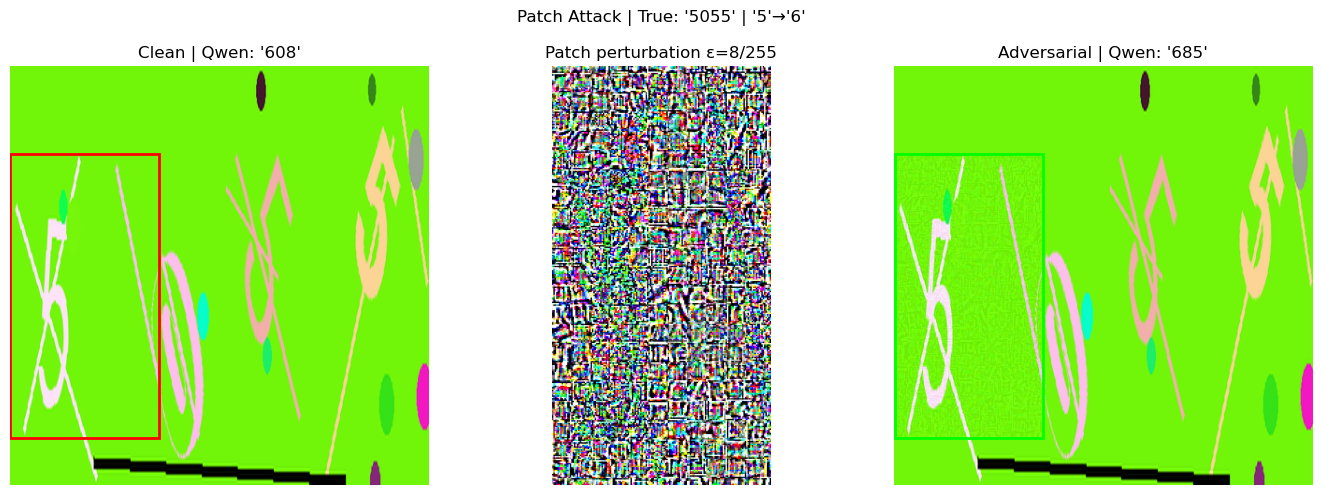

In [24]:
 # ── 5. Build attack inputs with FIXED label masking ───────────────────
first_digit    = int(captcha_text_numeric[0])
target_digit   = (first_digit + 1) % 10
target_caption = str(target_digit)
print(f"Attacking: '{first_digit}' → target: '{target_digit}'")

prompt_text = "What is the first digit in this CAPTCHA?"
messages = [{"role": "user", "content": [
    {"type": "image", "image": captcha_image_numeric},
    {"type": "text",  "text": prompt_text}
]}]
text_prompt = surrogate_processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
full_prompt = text_prompt + target_caption

static_inputs = surrogate_processor(
    text=[full_prompt], images=[captcha_image_numeric], return_tensors="pt"
).to(device)

# Fixed: only supervise the target digit token(s)
target_ids = surrogate_processor.tokenizer(
    target_caption, return_tensors="pt", add_special_tokens=False
)["input_ids"].to(device)
n_target_tokens = target_ids.shape[1]

labels = static_inputs["input_ids"].clone()
labels[:, :-n_target_tokens] = -100

input_ids      = static_inputs["input_ids"]
attention_mask = static_inputs["attention_mask"]
image_grid_thw = static_inputs.get("image_grid_thw")

print(f"Total sequence length : {input_ids.shape[1]}")
print(f"Supervised tokens     : {(labels != -100).sum().item()} ← should be {n_target_tokens}")

# ── 6. PGD Patch Attack ───────────────────────────────────────────────
EPSILON  = 8 / 255.0
ALPHA    = 1  / 255.0
STEPS    = 300
MOMENTUM = 0.9

patch_clean = x_clean_numeric[:, :, y1:y2, x1:x2].clone()
print(f"Patch shape: {patch_clean.shape}")

torch.manual_seed(42)
patch_adv = patch_clean + torch.empty_like(patch_clean).uniform_(-EPSILON, EPSILON)
patch_adv = torch.clamp(patch_adv, 0.0, 1.0).detach()

momentum_buf = torch.zeros_like(patch_clean)
best_loss    = float("inf")
best_patch   = patch_adv.clone()

surrogate_model.eval()
surrogate_model.gradient_checkpointing_enable()

print(f"\nLM-PGD patch attack | ε={EPSILON*255:.0f}/255 α={ALPHA*255:.0f}/255 steps={STEPS}")
print(f"{'Step':>6} | {'LM Loss':>10} | {'Best':>10}")
print("-" * 32)

for i in range(STEPS):
    patch_adv.requires_grad_(True)

    x_composed = torch.cat([
        x_clean_numeric[:, :, :y1, :],
        torch.cat([
            x_clean_numeric[:, :, y1:y2, :x1],
            patch_adv,
            x_clean_numeric[:, :, y1:y2, x2:]
        ], dim=3),
        x_clean_numeric[:, :, y2:, :]
    ], dim=2)

    pixel_values = preprocess_differentiable(x_composed).half()

    outputs = surrogate_model(
        input_ids=input_ids, attention_mask=attention_mask,
        pixel_values=pixel_values, image_grid_thw=image_grid_thw,
        labels=labels, use_cache=False,
    )
    loss = outputs.loss

    if torch.isnan(loss):
        patch_adv = patch_adv.detach()
        del outputs, loss, pixel_values
        gc.collect(); torch.cuda.empty_cache()
        continue

    loss.backward()

    with torch.no_grad():
        grad = patch_adv.grad
        grad = grad / (grad.abs().mean() + 1e-8)
        momentum_buf = MOMENTUM * momentum_buf + grad
        patch_adv = patch_adv - ALPHA * momentum_buf.sign()
        delta = torch.clamp(patch_adv - patch_clean, -EPSILON, EPSILON)
        patch_adv = torch.clamp(patch_clean + delta, 0.0, 1.0).detach()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_patch = patch_adv.clone()

    if i % 30 == 0:
        print(f"{i:>6} | {loss.item():>10.4f} | {best_loss:>10.4f}")

    del outputs, loss, pixel_values
    gc.collect(); torch.cuda.empty_cache()

print(f"\nBest LM loss: {best_loss:.4f}")

# ── 7. Compose + save ─────────────────────────────────────────────────
x_final = x_clean_numeric.clone()
x_final[:, :, y1:y2, x1:x2] = best_patch
adv_full_pil = Image.fromarray(
    (x_final.squeeze(0).permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
)
adv_full_pil.save("Captcha/adversarial_captcha_patch.png")
print("Saved Captcha/adversarial_captcha_patch.png")

# ── 8. Evaluate ───────────────────────────────────────────────────────
def query_captcha(pil_image, label=""):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": pil_image},
        {"type": "text",  "text": "What digits are shown in this CAPTCHA image? Just output the digits, nothing else."}
    ]}]
    text = surrogate_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = surrogate_processor(
        text=[text], images=image_inputs, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        out = surrogate_model.generate(**inputs, max_new_tokens=20)
    response = surrogate_processor.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()
    print(f"[{label}] → '{response}'")
    return response

clean_response = query_captcha(captcha_image_numeric, "CLEAN")
adv_response   = query_captcha(adv_full_pil,          "ADVERSARIAL")

print(f"\nTrue answer   : '{captcha_text_numeric}'")
print(f"Clean output  : '{clean_response}'")
print(f"Adv output    : '{adv_response}'")
print(f"Attack success: {'✓ YES' if clean_response != adv_response else '✗ NO'}")

# ── 9. Visualise ──────────────────────────────────────────────────────
delta_vis = (best_patch - patch_clean).squeeze(0).permute(1,2,0).cpu().numpy()
delta_vis = (delta_vis + EPSILON) / (2 * EPSILON)
delta_vis = np.clip(delta_vis, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(captcha_image_numeric)
axes[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none'))
axes[0].set_title(f"Clean | Qwen: '{clean_response}'"); axes[0].axis("off")

axes[1].imshow(delta_vis)
axes[1].set_title(f"Patch perturbation ε={EPSILON*255:.0f}/255"); axes[1].axis("off")

axes[2].imshow(adv_full_pil)
axes[2].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none'))
axes[2].set_title(f"Adversarial | Qwen: '{adv_response}'"); axes[2].axis("off")

plt.suptitle(f"Patch Attack | True: '{captcha_text_numeric}' | '{first_digit}'→'{target_digit}'", fontsize=12)
plt.tight_layout()
plt.savefig("Captcha/patch_attack_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### My own Captcha

In [28]:
# ── Set Kaggle credentials securely via environment variables ─────────
import os

os.environ["KAGGLE_USERNAME"] = "arunjoseph19"   # ← fill this in
os.environ["KAGGLE_KEY"]      = "KGAT_79cad1d803cec7d2e4886c8bb15910c6"           # ← fill this in

os.makedirs("Captcha/kaggle", exist_ok=True)
os.system("pip install kaggle -q")
os.system("kaggle datasets download -d fournierp/captcha-version-2-images -p Captcha/kaggle --unzip")

files = os.listdir("Captcha/kaggle/samples")
print(f"Downloaded {len(files)} CAPTCHA images")
print(f"Sample filenames: {files[:5]}")

Dataset URL: https://www.kaggle.com/datasets/fournierp/captcha-version-2-images
License(s): other


100%|██████████| 17.4M/17.4M [00:00<00:00, 1.21GB/s]



Downloaded 1071 CAPTCHA images
Sample filenames: ['44xe8.png', 'c4527.png', 'yxd7m.png', 'n7ebx.png', 'my84e.png']


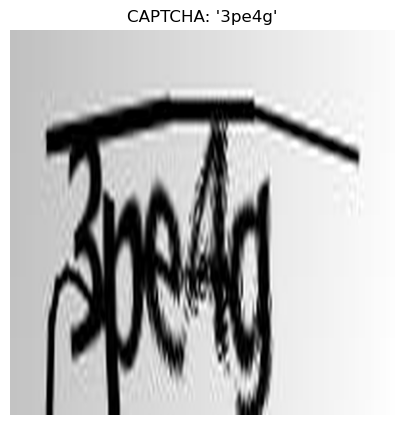

File   : 3pe4g.png
Answer : '3pe4g'
Tensor : torch.Size([1, 3, 448, 448])


In [29]:
# ── Load one random CAPTCHA from Kaggle dataset ───────────────────────
import os
import random
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

CAPTCHA_DIR = "Captcha/kaggle/samples"

all_files = [f for f in os.listdir(CAPTCHA_DIR) if f.endswith(".png")]
chosen_file = random.choice(all_files)

# Filename without extension = true answer
captcha_text_numeric = os.path.splitext(chosen_file)[0]
captcha_image_numeric = Image.open(
    os.path.join(CAPTCHA_DIR, chosen_file)
).convert("RGB").resize((448, 448), Image.LANCZOS)

x_clean_numeric = torch.tensor(
    np.array(captcha_image_numeric), dtype=torch.float32
).permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

plt.figure(figsize=(5, 5))
plt.imshow(captcha_image_numeric)
plt.title(f"CAPTCHA: '{captcha_text_numeric}'")
plt.axis("off")
plt.savefig("Captcha/kaggle_captcha_clean.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"File   : {chosen_file}")
print(f"Answer : '{captcha_text_numeric}'")
print(f"Tensor : {x_clean_numeric.shape}")

Attacking: '3' → target: '4'
Raw response: ```json
[
	{"bbox_2d": [45, 109, 178, 360], "label": "digit 3"}
]
```<|im_end|>
Raw bbox from Qwen: (45,109) → (178,360)
Mapped bbox (pixels): (35,99) → (188,370)


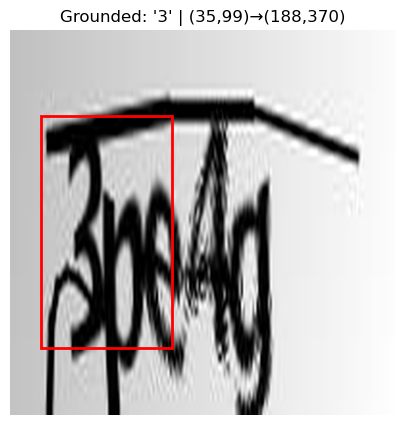

In [31]:
# ── Alphanumeric target ───────────────────────────────────────────────
CHARS = "0123456789abcdefghijklmnopqrstuvwxyz"
first_char  = captcha_text_numeric[0].lower()   # '3'
target_char = CHARS[(CHARS.index(first_char) + 1) % len(CHARS)]  # '4'
target_caption = target_char
print(f"Attacking: '{first_char}' → target: '{target_char}'")

# ── Grounding ─────────────────────────────────────────────────────────
bbox = get_first_digit_bbox(captcha_image_numeric, captcha_text_numeric)
x1, y1, x2, y2 = bbox

import matplotlib.patches as patches
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(captcha_image_numeric)
rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.set_title(f"Grounded: '{first_char}' | ({x1},{y1})→({x2},{y2})")
ax.axis("off")
plt.savefig("Captcha/kaggle_grounded.png", dpi=150, bbox_inches="tight")
plt.show()

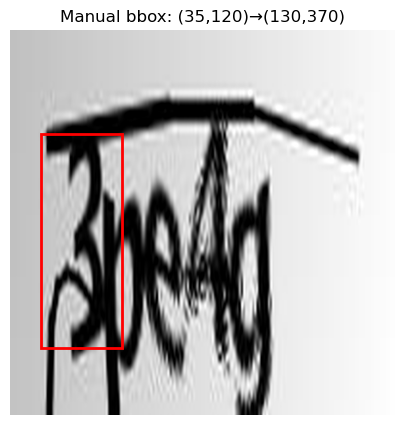

In [33]:
# ── Manual bbox override ──────────────────────────────────────────────
x1, y1, x2, y2 = 35, 120, 130, 370  # ← change these

import matplotlib.patches as patches
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(captcha_image_numeric)
rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.set_title(f"Manual bbox: ({x1},{y1})→({x2},{y2})")
ax.axis("off")
plt.show()

Attacking: '3' → target: '4'
Qwen grid: T=1 H=32 W=32 → 448x448
Total sequence length : 288
Supervised tokens     : 1 ← should be 1
Patch shape: torch.Size([1, 3, 250, 95])

LM-PGD patch attack | ε=16/255 α=1/255 steps=300
  Step |    LM Loss |       Best
--------------------------------
     0 |     9.7853 |     9.7853
    30 |     0.2975 |     0.2975
    60 |     0.0033 |     0.0021
    90 |     0.0007 |     0.0007
   120 |     1.0893 |     0.0000
   150 |     0.0002 |     0.0000
   180 |     0.0014 |     0.0000
   210 |     0.0000 |     0.0000
   240 |     0.0119 |     0.0000
   270 |     0.0321 |     0.0000

Best LM loss: 0.0000
Saved Captcha/adversarial_kaggle_patch.png
[CLEAN] → '3pe4g'
[ADVERSARIAL] → '3e5g'

True answer   : '3pe4g'
Clean output  : '3pe4g'
Adv output    : '3e5g'
Attack success: ✓ YES


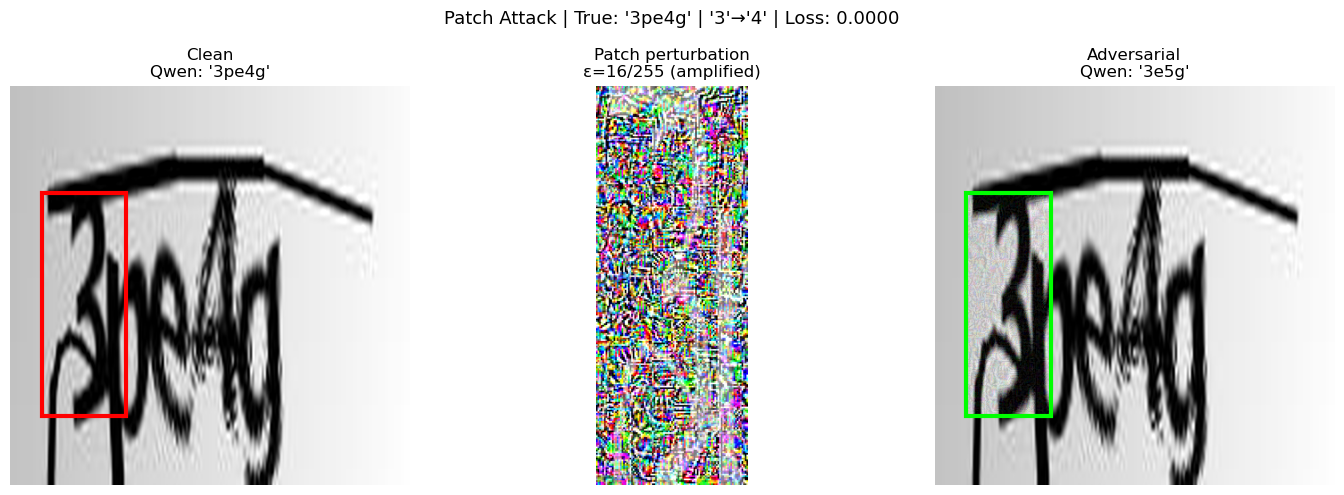

In [34]:
# ── Attack on Kaggle CAPTCHA ──────────────────────────────────────────
import gc

# ── Alphanumeric target ───────────────────────────────────────────────
CHARS = "0123456789abcdefghijklmnopqrstuvwxyz"
first_char     = captcha_text_numeric[0].lower()
target_char    = CHARS[(CHARS.index(first_char) + 1) % len(CHARS)]
target_caption = target_char
print(f"Attacking: '{first_char}' → target: '{target_char}'")

# ── Differentiable preprocessor ───────────────────────────────────────
qwen_mean = torch.tensor([0.48145466, 0.4578275,  0.40821073]).view(1,3,1,1).to(device)
qwen_std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1).to(device)

static_check = surrogate_processor(
    text=["dummy"], images=[captcha_image_numeric], return_tensors="pt"
).to(device)
image_grid_thw_check = static_check.get("image_grid_thw")
PATCH_SIZE = 14; TEMPORAL_PATCH = 2; MERGE_SIZE = 2
GRID_T = int(image_grid_thw_check[0][0].item())
GRID_H = int(image_grid_thw_check[0][1].item())
GRID_W = int(image_grid_thw_check[0][2].item())
TARGET_H = GRID_H * PATCH_SIZE
TARGET_W = GRID_W * PATCH_SIZE
print(f"Qwen grid: T={GRID_T} H={GRID_H} W={GRID_W} → {TARGET_H}x{TARGET_W}")

def preprocess_differentiable(x):
    x_resized = F.interpolate(x, size=(TARGET_H, TARGET_W),
                               mode="bilinear", align_corners=False)
    x_norm = (x_resized - qwen_mean) / qwen_std
    x_t = x_norm.squeeze(0).unsqueeze(0).expand(TEMPORAL_PATCH, -1, -1, -1)
    C = 3
    patches_t = x_t.reshape(
        GRID_T, TEMPORAL_PATCH, C,
        GRID_H // MERGE_SIZE, MERGE_SIZE, PATCH_SIZE,
        GRID_W // MERGE_SIZE, MERGE_SIZE, PATCH_SIZE,
    )
    patches_t = patches_t.permute(0, 3, 6, 4, 7, 2, 1, 5, 8)
    patches_t = patches_t.reshape(
        GRID_T * GRID_H * GRID_W,
        C * TEMPORAL_PATCH * PATCH_SIZE * PATCH_SIZE
    )
    return patches_t

# ── Build attack inputs ───────────────────────────────────────────────
prompt_text = "What is the first character in this CAPTCHA?"
messages = [{"role": "user", "content": [
    {"type": "image", "image": captcha_image_numeric},
    {"type": "text",  "text": prompt_text}
]}]
text_prompt = surrogate_processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
full_prompt = text_prompt + target_caption

static_inputs = surrogate_processor(
    text=[full_prompt], images=[captcha_image_numeric], return_tensors="pt"
).to(device)

# Fixed label masking — only supervise target token
target_ids = surrogate_processor.tokenizer(
    target_caption, return_tensors="pt", add_special_tokens=False
)["input_ids"].to(device)
n_target_tokens = target_ids.shape[1]

labels = static_inputs["input_ids"].clone()
labels[:, :-n_target_tokens] = -100

input_ids      = static_inputs["input_ids"]
attention_mask = static_inputs["attention_mask"]
image_grid_thw = static_inputs.get("image_grid_thw")

print(f"Total sequence length : {input_ids.shape[1]}")
print(f"Supervised tokens     : {(labels != -100).sum().item()} ← should be {n_target_tokens}")

# ── PGD patch attack ──────────────────────────────────────────────────
EPSILON  = 16 / 255.0
ALPHA    = 1  / 255.0
STEPS    = 300
MOMENTUM = 0.9

patch_clean = x_clean_numeric[:, :, y1:y2, x1:x2].clone()
print(f"Patch shape: {patch_clean.shape}")

torch.manual_seed(42)
patch_adv = patch_clean + torch.empty_like(patch_clean).uniform_(-EPSILON, EPSILON)
patch_adv = torch.clamp(patch_adv, 0.0, 1.0).detach()

momentum_buf = torch.zeros_like(patch_clean)
best_loss    = float("inf")
best_patch   = patch_adv.clone()

surrogate_model.eval()
surrogate_model.gradient_checkpointing_enable()

print(f"\nLM-PGD patch attack | ε={EPSILON*255:.0f}/255 α={ALPHA*255:.0f}/255 steps={STEPS}")
print(f"{'Step':>6} | {'LM Loss':>10} | {'Best':>10}")
print("-" * 32)

for i in range(STEPS):
    patch_adv.requires_grad_(True)

    x_composed = torch.cat([
        x_clean_numeric[:, :, :y1, :],
        torch.cat([
            x_clean_numeric[:, :, y1:y2, :x1],
            patch_adv,
            x_clean_numeric[:, :, y1:y2, x2:]
        ], dim=3),
        x_clean_numeric[:, :, y2:, :]
    ], dim=2)

    pixel_values = preprocess_differentiable(x_composed).half()

    outputs = surrogate_model(
        input_ids=input_ids, attention_mask=attention_mask,
        pixel_values=pixel_values, image_grid_thw=image_grid_thw,
        labels=labels, use_cache=False,
    )
    loss = outputs.loss

    if torch.isnan(loss):
        patch_adv = patch_adv.detach()
        del outputs, loss, pixel_values
        gc.collect(); torch.cuda.empty_cache()
        continue

    loss.backward()

    with torch.no_grad():
        grad = patch_adv.grad
        grad = grad / (grad.abs().mean() + 1e-8)
        momentum_buf = MOMENTUM * momentum_buf + grad
        patch_adv = patch_adv - ALPHA * momentum_buf.sign()
        delta = torch.clamp(patch_adv - patch_clean, -EPSILON, EPSILON)
        patch_adv = torch.clamp(patch_clean + delta, 0.0, 1.0).detach()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_patch = patch_adv.clone()

    if i % 30 == 0:
        print(f"{i:>6} | {loss.item():>10.4f} | {best_loss:>10.4f}")

    del outputs, loss, pixel_values
    gc.collect(); torch.cuda.empty_cache()

print(f"\nBest LM loss: {best_loss:.4f}")

# ── Compose final adversarial image ───────────────────────────────────
x_final = x_clean_numeric.clone()
x_final[:, :, y1:y2, x1:x2] = best_patch
adv_full_pil = Image.fromarray(
    (x_final.squeeze(0).permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
)
adv_full_pil.save("Captcha/adversarial_kaggle_patch.png")
print("Saved Captcha/adversarial_kaggle_patch.png")

# ── Evaluate ──────────────────────────────────────────────────────────
def query_captcha(pil_image, label=""):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": pil_image},
        {"type": "text",  "text": "What characters are shown in this CAPTCHA image? Just output the characters, nothing else."}
    ]}]
    text = surrogate_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = surrogate_processor(
        text=[text], images=image_inputs, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        out = surrogate_model.generate(**inputs, max_new_tokens=20)
    response = surrogate_processor.decode(
        out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()
    print(f"[{label}] → '{response}'")
    return response

clean_response = query_captcha(captcha_image_numeric, "CLEAN")
adv_response   = query_captcha(adv_full_pil,          "ADVERSARIAL")

print(f"\nTrue answer   : '{captcha_text_numeric}'")
print(f"Clean output  : '{clean_response}'")
print(f"Adv output    : '{adv_response}'")
print(f"Attack success: {'✓ YES' if clean_response != adv_response else '✗ NO'}")

# ── Visualise ─────────────────────────────────────────────────────────
plt.close('all')
delta_vis = (best_patch - patch_clean).squeeze(0).permute(1,2,0).cpu().numpy()
delta_vis = (delta_vis + EPSILON) / (2 * EPSILON)
delta_vis = np.clip(delta_vis, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(captcha_image_numeric)
axes[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                  linewidth=3, edgecolor='red', facecolor='none'))
axes[0].set_title(f"Clean\nQwen: '{clean_response}'", fontsize=12)
axes[0].axis("off")

axes[1].imshow(delta_vis)
axes[1].set_title(f"Patch perturbation\nε={EPSILON*255:.0f}/255 (amplified)", fontsize=12)
axes[1].axis("off")

axes[2].imshow(adv_full_pil)
axes[2].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                  linewidth=3, edgecolor='lime', facecolor='none'))
axes[2].set_title(f"Adversarial\nQwen: '{adv_response}'", fontsize=12)
axes[2].axis("off")

plt.suptitle(
    f"Patch Attack | True: '{captcha_text_numeric}' | '{first_char}'→'{target_char}' | Loss: {best_loss:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("Captcha/kaggle_patch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()